In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/SIH2026/Categorised IOVNB (V) Dataset/V Dataset/S (Driver A)/S1'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir(DATASET_PATH))

['V-S1.JPG', 'V-S1.csv']


In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np

file_path = os.path.join(DATASET_PATH, 'V-S1.csv')
df = pd.read_csv(file_path)
df.head()

,No of GPS Satellites Available,Time Since Start of Day (seconds),Latitude (degrees),Longitude (degrees),Velocity (km/hr),Heading (degrees),Height (km),Vertical velocity (km/hr),Sample period (seconds),Steering Angle (degrees),...,Gear Requested (Number fof gear employed 1-5),Gear (Number fof gear employed 1-5),Engine Speed (rev/min),Coolant Temperature (degrees),Clutch Position (0 or 1),Brake Pressure (psi),Brake Position (0 or 1),Battery Voltage (volts),Air Temperature (degrees),Accelerator Pedal Position (0 or 1)
0,10.0,32864.7,52.401837,-1.504984,23.436,240.610,109.52,0.15,0.1,11.599980,...,2.0,3.0,2139.0,39.0,0.0,-0.220001,0.0,14.3,15.0,19.0
1,10.0,32864.8,52.401834,-1.504992,23.598,240.844,109.55,0.17,0.1,4.200012,...,2.0,3.0,2160.0,39.0,0.0,0.009979,0.0,14.2,15.0,18.5
2,10.0,32864.9,52.401831,-1.505001,24.138,241.578,109.56,0.17,0.1,0.000000,...,2.0,3.0,2183.0,39.0,0.0,-0.220001,0.0,14.2,15.0,17.0
3,10.0,32865.0,52.401829,-1.505009,24.066,241.355,109.58,0.18,0.1,0.000000,...,2.0,3.0,2191.0,39.0,0.0,0.009979,0.0,14.2,15.0,15.0
4,10.0,32865.1,52.401826,-1.505018,24.523,242.411,109.59,0.18,0.1,0.000000,...,2.0,3.0,2188.0,39.0,0.0,-0.220001,0.0,14.2,15.0,14.5


In [ ]:
from pathlib import Path

data_dir = Path(DATASET_PATH)
# List all files matching a pattern
files = list(data_dir.glob('*'))
print(f"Total items found: {len(files)}")

Total items found: 2


In [ ]:
import pandas as pd
import numpy as np

# Load your file
df = pd.read_csv(file_path)
print("Columns present:", df.columns.tolist())
print(df.head(3))

Columns present: ['No of GPS Satellites Available', ' Time Since Start of Day (seconds)', ' Latitude (degrees)', ' Longitude (degrees)', ' Velocity (km/hr)', ' Heading (degrees)', ' Height (km)', ' Vertical velocity (km/hr)', ' Sample period (seconds)', ' Steering Angle (degrees)', ' Wheel Speed Front Left (rad/sec)', ' Wheel Speed Front Right (rad/sec)', ' Wheel Speed Rear Left (rad/sec)', ' Wheel Speed Rear Right (rad/sec)', ' Yaw Rate (deg/sec)', ' Indicated Vehicle Speed (km/hr)', ' Indicated Longitudinal Acceleration (g)', ' Indicated Lateral Acceleration (g)', ' Handbrake (0 or 1)', ' Gear Requested (Number fof gear employed 1-5)', ' Gear (Number fof gear employed 1-5)', ' Engine Speed (rev/min)', ' Coolant Temperature (degrees)', ' Clutch Position (0 or 1)', ' Brake Pressure (psi)', ' Brake Position (0 or 1)', ' Battery Voltage (volts)', ' Air Temperature (degrees)', ' Accelerator Pedal Position (0 or 1)']
   No of GPS Satellites Available   Time Since Start of Day (seconds)  \


In [ ]:
from sklearn.preprocessing import StandardScaler

# Update these lists with the exact column names from cell 29 (including leading spaces)
feature_cols = [
    ' Indicated Longitudinal Acceleration (g)',
    ' Indicated Lateral Acceleration (g)',
    ' Yaw Rate (deg/sec)',
    ' Velocity (km/hr)'
]

target_cols = [
    ' Velocity (km/hr)',
    ' Vertical velocity (km/hr)'
]

# Scale input features
feature_scaler = StandardScaler()
scaled_features = feature_scaler.fit_transform(df[feature_cols])

# Scale targets
target_scaler = StandardScaler()
scaled_targets = target_scaler.fit_transform(df[target_cols])
targets = scaled_targets # Use the scaled targets for your sequences

# ... keep the rest of your sliding window function the same ...

In [ ]:
def create_sequences(features, targets, window_size):
    X, y = [], []
    for i in range(len(features) - window_size):
        # Take a window of past features
        X.append(features[i:(i + window_size)])
        # Predict the target at the next time step
        y.append(targets[i + window_size])
    return np.array(X), np.array(y)

# Define how many past time steps the model should look at
# Note: Your sample period is 0.1s, so a window of 20 equals 2 seconds of history
window_size = 20

X, y = create_sequences(scaled_features, targets, window_size)

print(f"Feature sequence shape (X): {X.shape}")
print(f"Target sequence shape (y): {y.shape}")

Feature sequence shape (X): (51770, 20, 4)
Target sequence shape (y): (51770, 2)


In [ ]:
from sklearn.model_selection import train_test_split

# Split 80% for training, 20% for testing (shuffle=False preserves time order)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Testing targets shape: {y_test.shape}")

Training features shape: (41416, 20, 4)
Testing features shape: (10354, 20, 4)
Training targets shape: (41416, 2)
Testing targets shape: (10354, 2)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(y_train.shape[1]) # Output layer matches the number of targets (2)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,810 (77.38 KB)

 Trainable params: 19,810 (77.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model and store the results in 'history'
# You can adjust epochs (number of passes) and batch_size later to improve performance
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.4493 - mae: 0.3838 - val_loss: 0.2785 - val_mae: 0.2695
Epoch 2/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 0.3118 - mae: 0.3123 - val_loss: 0.1913 - val_mae: 0.2151
Epoch 3/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.2565 - mae: 0.2719 - val_loss: 0.1549 - val_mae: 0.2174
Epoch 4/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.2388 - mae: 0.2566 - val_loss: 0.1324 - val_mae: 0.1814
Epoch 5/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.2266 - mae: 0.2475 - val_loss: 0.1366 - val_mae: 0.2025
Epoch 6/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.2195 - mae: 0.2420 - val_loss: 0.1523 - val_mae: 0.1982
Epoch 7/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.2113 - mae: 0.2364 - val_loss: 0.1459 - val_mae: 0.1878
Epoch 8/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.2037 - mae: 0.2323 - val_loss: 0.1379 - val_mae: 0.1880
Epoch 9/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 

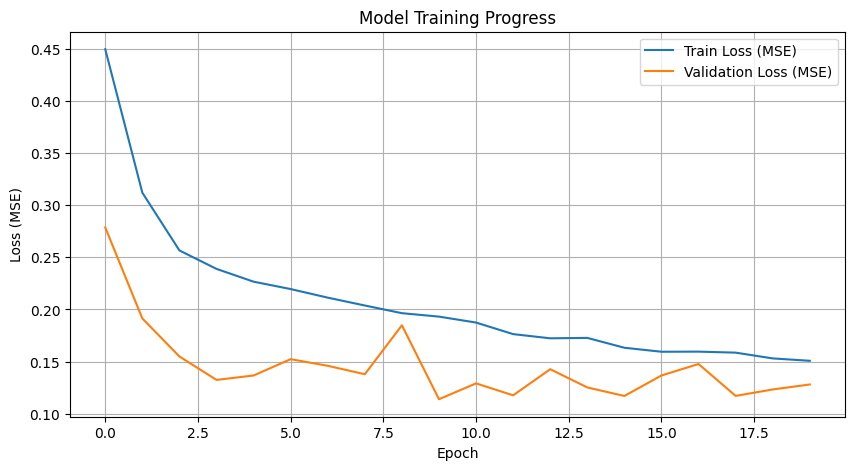

In [ ]:
import matplotlib.pyplot as plt

# Plot the Training and Validation Loss (Mean Squared Error)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Training Progress')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


model = Sequential([

    LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(y_train.shape[1])
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.4794 - mae: 0.4127 - val_loss: 0.2938 - val_mae: 0.2729
Epoch 2/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.4102 - mae: 0.3752 - val_loss: 0.2494 - val_mae: 0.2604
Epoch 3/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3261 - mae: 0.3326 - val_loss: 0.2533 - val_mae: 0.2513
Epoch 4/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.2771 - mae: 0.2986 - val_loss: 0.1838 - val_mae: 0.2236
Epoch 5/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2584 - mae: 0.2846 - val_loss: 0.1688 - val_mae: 0.2065
Epoch 6/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.2439 - mae: 0.2729 - val_loss: 0.1560 - val_mae: 0.2088
Epoch 7/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2384 - mae: 0.2674 - val_loss: 0.1325 - val_mae: 0.1761
Epoch 8/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.2325 - mae: 0.2623 - val_loss: 0.1378 - val_mae: 0.2035
Epoch 9/30
648/648 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms

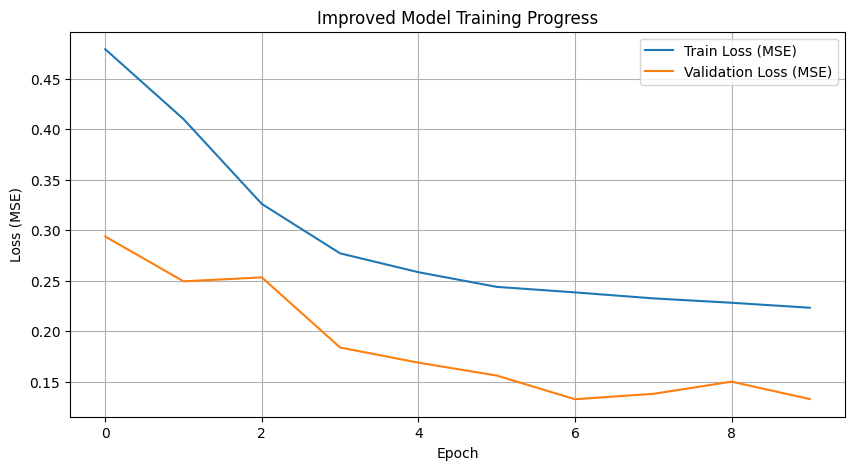

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Improved Model Training Progress')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate the model on the test data
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test MSE (Loss): {test_loss:.4f}")
print(f"Final Test MAE (Mean Absolute Error): {test_mae:.4f}")

Final Test MSE (Loss): 0.1325
Final Test MAE (Mean Absolute Error): 0.1761


324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


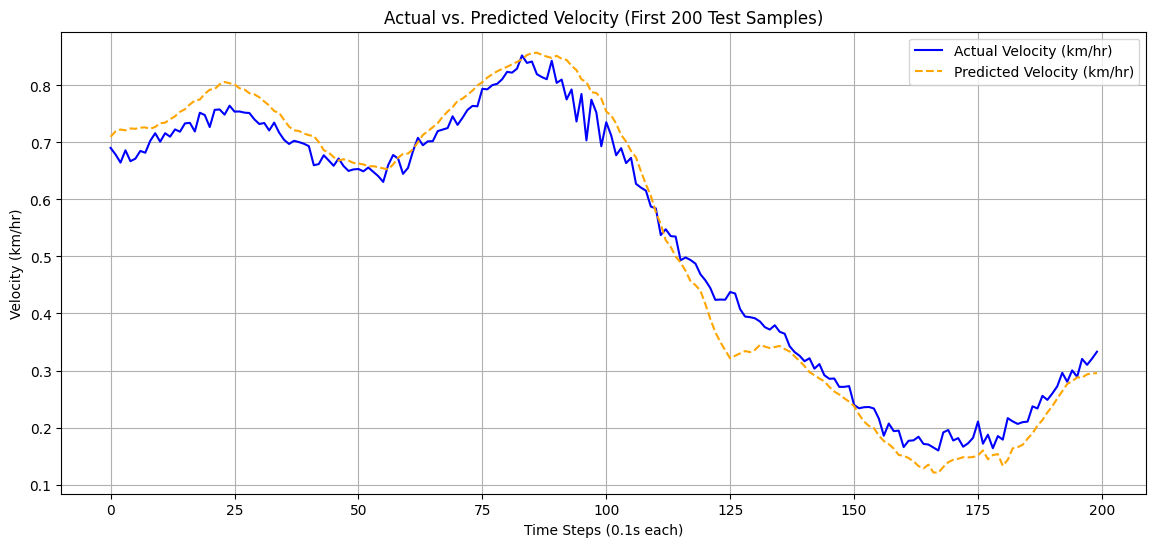

In [ ]:
# Generate predictions
predictions = model.predict(X_test)

# Plot Actual vs Predicted for the first target: Velocity
plt.figure(figsize=(14, 6))
plt.plot(y_test[:200, 0], label='Actual Velocity (km/hr)', color='blue')
plt.plot(predictions[:200, 0], label='Predicted Velocity (km/hr)', color='orange', linestyle='dashed')
plt.title('Actual vs. Predicted Velocity (First 200 Test Samples)')
plt.xlabel('Time Steps (0.1s each)')
plt.ylabel('Velocity (km/hr)')
plt.legend()
plt.grid(True)
plt.show()

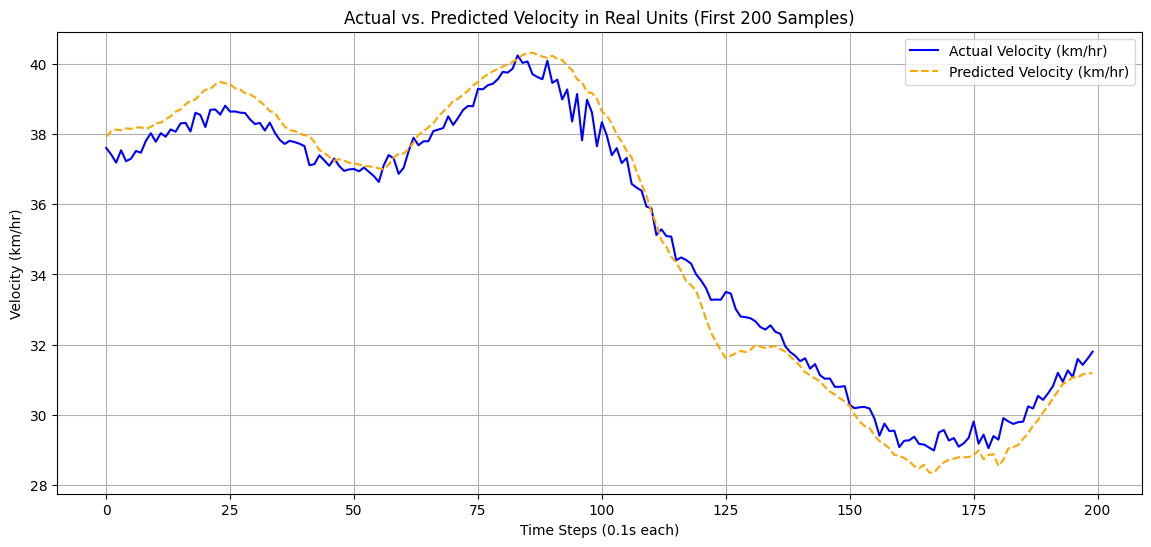

Real-world Test MAE for Velocity: 0.78 km/hr


In [ ]:
# Convert scaled predictions and actuals back to original km/hr scale
real_predictions = target_scaler.inverse_transform(predictions)
real_y_test = target_scaler.inverse_transform(y_test)

# Plot Actual vs Predicted in real km/hr
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
# Plotting the first 200 time steps of the unscaled Velocity (target index 0)
plt.plot(real_y_test[:200, 0], label='Actual Velocity (km/hr)', color='blue')
plt.plot(real_predictions[:200, 0], label='Predicted Velocity (km/hr)', color='orange', linestyle='dashed')
plt.title('Actual vs. Predicted Velocity in Real Units (First 200 Samples)')
plt.xlabel('Time Steps (0.1s each)')
plt.ylabel('Velocity (km/hr)')
plt.legend()
plt.grid(True)
plt.show()

# Let's also check the actual real-world Mean Absolute Error in km/hr
from sklearn.metrics import mean_absolute_error
real_mae = mean_absolute_error(real_y_test[:, 0], real_predictions[:, 0])
print(f"Real-world Test MAE for Velocity: {real_mae:.2f} km/hr")

In [ ]:
# Save the model architecture and trained weights
model.save('velocity_kinematics_lstm.h5')
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import shutil
import joblib

# 1. Move the model to your Google Drive
drive_path = '/content/drive/MyDrive/SIH2026/velocity_kinematics_lstm.h5'
shutil.copy('velocity_kinematics_lstm.h5', drive_path)
print("Model permanently saved to Drive!")

# 2. Save your trained scalers to Drive
joblib.dump(feature_scaler, '/content/drive/MyDrive/SIH2026/feature_scaler.pkl')
joblib.dump(target_scaler, '/content/drive/MyDrive/SIH2026/target_scaler.pkl')
print("Scalers saved to Drive!")

Model permanently saved to Drive!
Scalers saved to Drive!


In [ ]:
from tensorflow.keras.models import load_model
import joblib
import pandas as pd

# Load your trained model (without compiling) and scalers from Drive
model = load_model('/content/drive/MyDrive/SIH2026/velocity_kinematics_lstm.h5', compile=False)

feature_scaler = joblib.load('/content/drive/MyDrive/SIH2026/feature_scaler.pkl')
target_scaler = joblib.load('/content/drive/MyDrive/SIH2026/target_scaler.pkl')

print("Model and scalers loaded successfully!")

Model and scalers loaded successfully!


In [ ]:
# Load Driver B's data
new_data_path = '/content/drive/MyDrive/SIH2026/Categorised IOVNB (V) Dataset/V Dataset/M (Driver B)/V-M.csv'
df_new = pd.read_csv(new_data_path)

# Apply a rolling mean to smooth the sensor noise (same as training)
df_new[feature_cols] = df_new[feature_cols].rolling(window=10, min_periods=1).mean()

# CRITICAL: Use .transform() instead of .fit_transform() on new data
# This applies the exact same mathematical scaling that Driver A used
scaled_features_new = feature_scaler.transform(df_new[feature_cols])
scaled_targets_new = target_scaler.transform(df_new[target_cols])

In [ ]:
# Create sequences using the same sliding window function
window_size = 20
X_new, y_new = create_sequences(scaled_features_new, scaled_targets_new, window_size)

# Generate predictions for the new driver
new_predictions = model.predict(X_new)

# Inverse transform to get real km/hr values
real_new_predictions = target_scaler.inverse_transform(new_predictions)
real_y_new = target_scaler.inverse_transform(y_new)

# Calculate Mean Absolute Error to see how well it generalized
from sklearn.metrics import mean_absolute_error
new_mae = mean_absolute_error(real_y_new[:, 0], real_new_predictions[:, 0])
print(f"Driver B Test MAE for Velocity: {new_mae:.2f} km/hr")

3312/3312 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
Driver B Test MAE for Velocity: 1.15 km/hr


In [ ]:
print(df.columns.tolist())

['No of GPS Satellites Available', ' Time Since Start of Day (seconds)', ' Latitude (degrees)', ' Longitude (degrees)', ' Velocity (km/hr)', ' Heading (degrees)', ' Height (km)', ' Vertical velocity (km/hr)', ' Sample period (seconds)', ' Steering Angle (degrees)', ' Wheel Speed Front Left (rad/sec)', ' Wheel Speed Front Right (rad/sec)', ' Wheel Speed Rear Left (rad/sec)', ' Wheel Speed Rear Right (rad/sec)', ' Yaw Rate (deg/sec)', ' Indicated Vehicle Speed (km/hr)', ' Indicated Longitudinal Acceleration (g)', ' Indicated Lateral Acceleration (g)', ' Handbrake (0 or 1)', ' Gear Requested (Number fof gear employed 1-5)', ' Gear (Number fof gear employed 1-5)', ' Engine Speed (rev/min)', ' Coolant Temperature (degrees)', ' Clutch Position (0 or 1)', ' Brake Pressure (psi)', ' Brake Position (0 or 1)', ' Battery Voltage (volts)', ' Air Temperature (degrees)', ' Accelerator Pedal Position (0 or 1)']


In [ ]:
import numpy as np

def dead_reckon(velocity, yaw_rate, dt=0.1):
    """
    velocity: array of speed (km/hr) — convert to m/s first
    yaw_rate: array of yaw rate (deg/sec) — convert to rad/sec
    Returns: x, y position arrays (in meters)
    """
    v_ms = velocity / 3.6                     # km/hr -> m/s
    yaw_rad = np.radians(yaw_rate)             # deg/s -> rad/s

    heading = np.cumsum(yaw_rad * dt)          # integrate yaw rate -> heading angle
    dx = v_ms * np.cos(heading) * dt
    dy = v_ms * np.sin(heading) * dt

    x = np.cumsum(dx)
    y = np.cumsum(dy)
    return x, y

In [ ]:
import numpy as np

lat_col = ' Latitude (degrees)'
lon_col = ' Longitude (degrees)'
yaw_col = ' Yaw Rate (deg/sec)'

R = 6371000  # Earth radius, meters

def latlon_to_xy(lat, lon):
    lat0, lon0 = np.radians(lat[0]), np.radians(lon[0])
    lat_rad, lon_rad = np.radians(lat), np.radians(lon)
    x = R * (lon_rad - lon0) * np.cos(lat0)
    y = R * (lat_rad - lat0)
    return x, y

In [ ]:
test_start = window_size + len(y_train)   # first df row index in the test set

lat_test = df[lat_col].values[test_start : test_start + len(y_test)]
lon_test = df[lon_col].values[test_start : test_start + len(y_test)]
yaw_test = df[yaw_col].values[test_start : test_start + len(y_test)]

x_true, y_true = latlon_to_xy(lat_test, lon_test)

In [ ]:
def dead_reckon(velocity_kmh, yaw_rate_dps, dt=0.1, heading0=0.0):
    v_ms = velocity_kmh / 3.6
    heading = heading0 + np.cumsum(np.radians(yaw_rate_dps) * dt)
    x = np.cumsum(v_ms * np.cos(heading) * dt)
    y = np.cumsum(v_ms * np.sin(heading) * dt)
    return x, y

heading_col = ' Heading (degrees)'
compass_heading_deg = df[heading_col].values[test_start]
math_heading_rad = np.radians(90 - compass_heading_deg)

x_pred, y_pred = dead_reckon(real_predictions[:, 0], yaw_test, heading0=math_heading_rad)

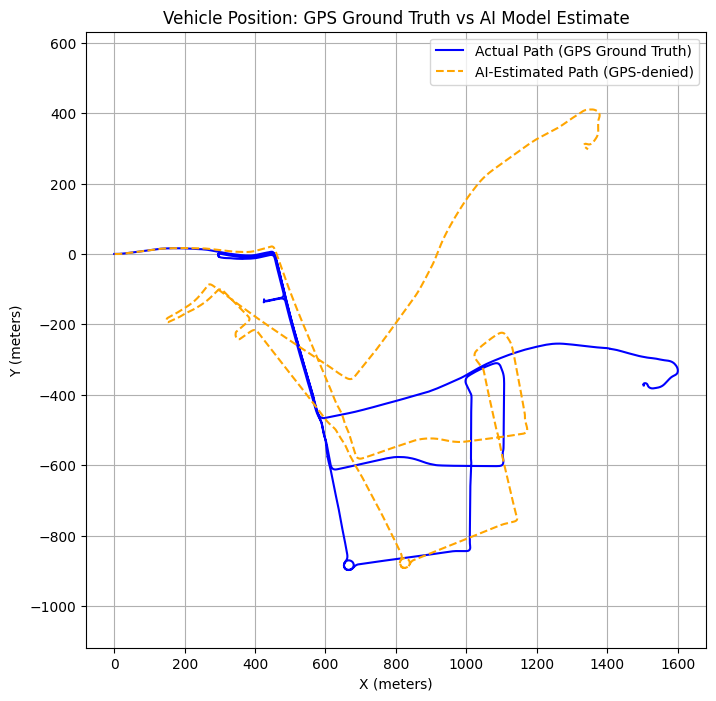

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.plot(x_true, y_true, label='Actual Path (GPS Ground Truth)', color='blue')
plt.plot(x_pred, y_pred, label='AI-Estimated Path (GPS-denied)', color='orange', linestyle='dashed')
plt.xlabel('X (meters)'); plt.ylabel('Y (meters)')
plt.title('Vehicle Position: GPS Ground Truth vs AI Model Estimate')
plt.legend(); plt.axis('equal'); plt.grid(True)
plt.show()

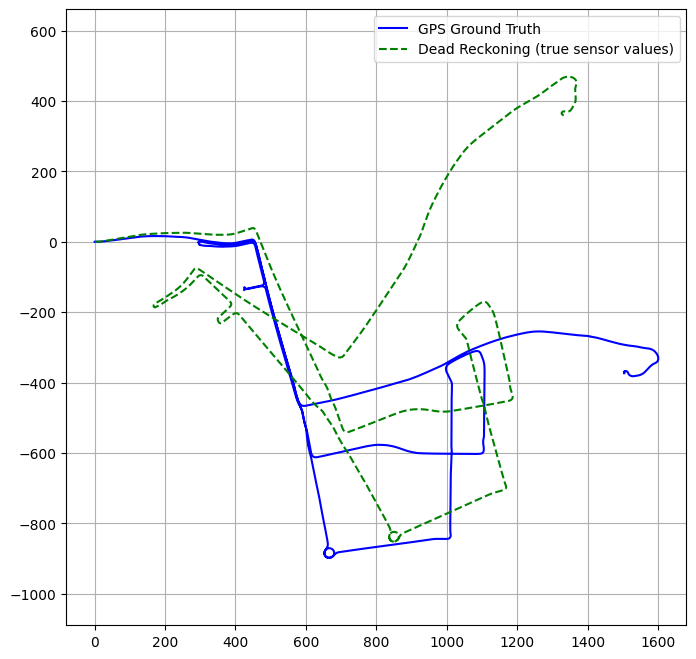

In [ ]:
# Sanity check: does pure sensor-based dead reckoning match GPS at all?
x_sanity, y_sanity = dead_reckon(real_y_test[:, 0], yaw_test, heading0=0.0)

plt.figure(figsize=(8, 8))
plt.plot(x_true, y_true, label='GPS Ground Truth', color='blue')
plt.plot(x_sanity, y_sanity, label='Dead Reckoning (true sensor values)', color='green', linestyle='dashed')
plt.legend(); plt.axis('equal'); plt.grid(True)
plt.show()

In [ ]:
final_drift = np.sqrt((x_true[-1] - x_pred[-1])**2 + (y_true[-1] - y_pred[-1])**2)
print(f"Final positional drift: {final_drift:.1f} meters over {len(x_true)*0.1:.0f} seconds")

Final positional drift: 688.7 meters over 1035 seconds
